# Sample Selection

In this notebook, we begin by loading the clean dataset obtained from the preprocessing stage. Next, we go through various steps to generate data that describe normal network behavior. Specifically, this phase involves detecting and removing features that are highly correlated with the Key Performance Indicator (KPI), identifying performance outliers and anomalies, and building an XGBoost regression model that characterizes normal network behavior. 

In this case, we utilize various functions from the ``scikit-learn`` library, a Python library that supports many supervised and unsupervised machine learning techniques. Additionally, we employ the ``matplotlib`` library, which provides several visualization tools to display our results. We also need the ``xgboost`` library to build the regression model that describes normal network behavior.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

import warnings
warnings.filterwarnings('ignore')

## Loading the Clean Dataset

This stage loads the clean dataset generated by the preprocessing module.

In [2]:
print('-----------------------------------------')
print('LOADING DATASET A FILE DOWNLOAD DATASET')
data_file = 'data/Op1_CapDL_NoSteps_wo_correlated_features.csv'
data = pd.read_csv(data_file, sep=",", decimal='.', low_memory = False)
data = data.drop(columns=['Unnamed: 0'])
print('Data Size:(%d, %d)'%(data.shape[0], data.shape[1]))
print('-----------------------------------------')
target_kpi = 'transfer.datarate'
kpi_aux    = data[target_kpi]
data.describe()

-----------------------------------------
LOADING DATASET A FILE DOWNLOAD DATASET
Data Size:(1001, 120)
-----------------------------------------


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,...,abs.segmentsizes.25.,abs.segmentsizes.50.,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1.001000e+03,1.001000e+03
mean,128.041958,23504.771229,19.445554,0.000999,645.926074,2.017982,2.334520e+06,1028.684316,62737.201798,231.181818,...,2597.134615,6170.843157,1.137196e+05,203.033966,0.000159,63.993007,236.949051,6.736559e+09,3.329800e+13,3.934347e+05
std,95.049736,11232.441681,35.021355,0.031607,3311.848603,46.315242,7.746871e+06,4453.186531,8786.050549,9.141931,...,457.538529,1642.232733,6.787134e+05,577.700565,0.000095,159.287303,1485.634821,1.424162e+10,2.990747e+13,1.984722e+05
min,0.000000,1299.000000,5.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,5308.000000,64.000000,...,660.000000,1327.000000,5.538000e+03,0.000000,0.000080,0.000000,0.000000,2.317959e+00,9.010940e+00,2.408967e+03
25%,62.000000,18357.000000,6.000000,0.000000,0.000000,0.000000,0.000000e+00,32.000000,65236.000000,232.000000,...,2776.000000,5552.000000,6.523600e+04,0.000000,0.000080,0.000000,0.000000,9.986515e+02,6.019258e+04,2.530839e+05
50%,117.000000,23260.000000,9.000000,0.000000,23.000000,0.000000,1.081380e+05,75.000000,65236.000000,232.000000,...,2776.000000,6940.000000,6.523600e+04,37.000000,0.000160,13.000000,3.000000,2.691650e+09,3.004338e+13,3.813481e+05
75%,176.000000,27219.000000,17.000000,0.000000,185.000000,0.000000,1.393763e+06,322.000000,65236.000000,232.000000,...,2776.000000,6940.000000,6.523600e+04,173.000000,0.000240,53.000000,26.000000,7.241105e+09,5.818665e+13,5.196789e+05
max,748.000000,105106.000000,521.000000,1.000000,31047.000000,1397.000000,8.789408e+07,41515.000000,65236.000000,232.000000,...,4164.000000,9716.000000,1.389992e+07,9177.000000,0.000400,1956.000000,15336.000000,1.970290e+11,1.836066e+14,1.275028e+06


## Performance Outlier and Anomaly Detection

In [3]:
data = data.loc[:,data.columns != target_kpi]
data[target_kpi] = np.log10(kpi_aux)

scaler    = StandardScaler()
detector0 = OneClassSVM(gamma='auto', kernel='poly', degree=3).fit(scaler.fit_transform(data))
anomaly0  = detector0.predict(scaler.fit_transform(data))
if (np.sum(anomaly0 == 1) > np.sum(anomaly0 == -1)):
    anomaly0 = -anomaly0
outliers_features = (anomaly0 == 1)
    
data_nrm = data[target_kpi].to_numpy() / np.std(data[target_kpi])
Q3 = np.quantile(data_nrm, 0.75) - np.mean(data_nrm)
if (Q3 != 0):
    med = np.median(data[target_kpi])
    MAD = (1/Q3) * np.median(np.absolute(data[target_kpi] - med))
    outliers_kpi = (data[target_kpi] > med + 3.0*MAD)|(data[target_kpi] < med - 3.0*MAD)
    
atypical = pd.DataFrame(columns=['outliers'])
atypical['outliers'] = outliers_kpi

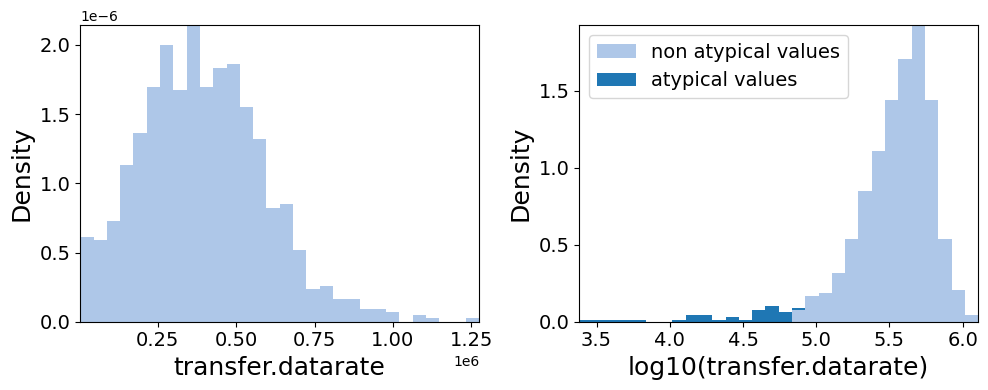

In [4]:
fig = plt.figure(figsize=(10,4), tight_layout=True)
ax = fig.add_subplot(1,2,1)
ax.hist(kpi_aux, 
        bins=30, 
        density = True,
        color=sns.color_palette("tab20")[1],
        stacked=True,
        )
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('transfer.datarate', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.autoscale(axis='both', tight=True)

anomaly_classes = np.unique(outliers_kpi)
ax = fig.add_subplot(1,2,2)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.autoscale(axis='both', tight=True)
plt.show()